<a href="https://colab.research.google.com/github/yanapvl/AI-text-detection/blob/main/%D0%BA%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Встановлення бібліотек
!pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib seaborn kaggle scipy statsmodels
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_PATH = '/content/drive/MyDrive/Kursova_AI_Models'
os.makedirs(SAVE_PATH, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#@title Завантаження датасету
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import time
import warnings
import random
import string
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)
from statsmodels.stats.contingency_tables import mcnemar

import torch
from torch.utils.data import Dataset
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)

warnings.filterwarnings('ignore')

# ── Відтворюваність ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── GPU-перевірка ─────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Пристрій: {device}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Пристрій: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


In [ ]:
# @title Налаштування Kaggle API

from google.colab import userdata
import json
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_creds = {
    'username': userdata.get('KAGGLE_USERNAME'),
    'key':      userdata.get('KAGGLE_KEY')
}
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

os.makedirs('./data', exist_ok=True)
!kaggle datasets download -d thedrcat/daigt-v2-train-dataset -p ./data/ --unzip -q
print('Датасет завантажено')
!ls -lh ./data/

Dataset URL: https://www.kaggle.com/datasets/thedrcat/daigt-v2-train-dataset
License(s): other
Датасет завантажено
total 98M
-rw-r--r-- 1 root root 98M May 22 05:40 train_v2_drcat_02.csv


In [ ]:
# @title  Завантаження та аналіз даних
DATA_PATH = './data/train_v2_drcat_02.csv'
df = pd.read_csv(DATA_PATH)

print('=' * 60)
print(f'  Розмір датасету : {df.shape[0]:,} рядків, {df.shape[1]} колонок')
print(f'  Колонки         : {df.columns.tolist()}')
print(f'  Пропущені знач. : {df.isnull().sum().sum()}')
print('=' * 60)

print('\nРозподіл класів:')
class_counts = df['label'].value_counts().sort_index()
for label, count in class_counts.items():
    name = 'Людина' if label == 0 else 'ШІ'
    print(f'  {name} ({label}): {count:,} ({count / len(df) * 100:.1f}%)')

df['text_length'] = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()

length_stats = df.groupby('label')[['text_length', 'word_count']].agg(['mean', 'median', 'min', 'max'])
length_stats.index = ['Людина', 'ШІ']

print('\nСтатистика довжини текстів:')
print(length_stats.round(0).to_string())

  Розмір датасету : 44,868 рядків, 5 колонок
  Колонки         : ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven']
  Пропущені знач. : 0

Розподіл класів:
  Людина (0): 27,371 (61.0%)
  ШІ (1): 17,497 (39.0%)

Статистика довжини текстів:
       text_length                     word_count                  
              mean  median  min    max       mean median  min   max
Людина      2349.0  2132.0  691  18322      418.0  383.0  143  1656
ШІ          2009.0  1973.0   48   5078      329.0  328.0    4   818


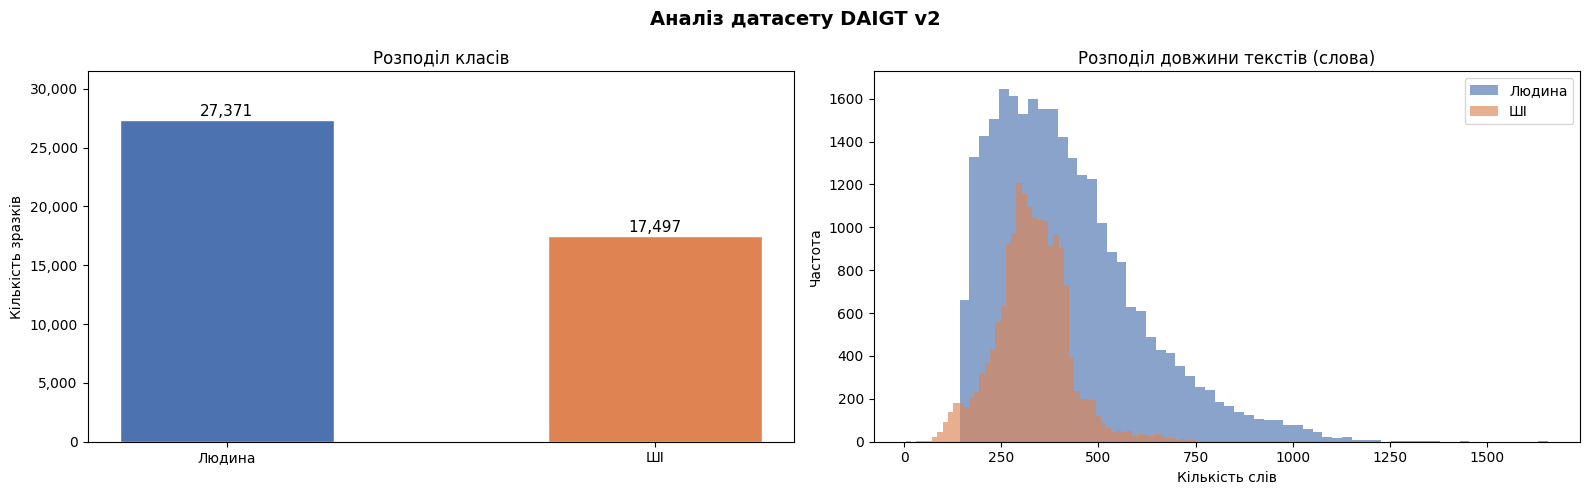

Графік збережено: eda_plots.png


In [ ]:
# @title Візуалізація даних
COLORS = {0: '#4C72B0', 1: '#DD8452'}
LABELS = {0: 'Людина', 1: 'ШІ'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Аналіз датасету DAIGT v2', fontsize=14, fontweight='bold')

# Розподіл класів
bars = axes[0].bar(
    [LABELS[0], LABELS[1]],
    class_counts.values,
    color=[COLORS[0], COLORS[1]],
    edgecolor='white', width=0.5
)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{val:,}', ha='center', fontsize=11
    )
axes[0].set_title('Розподіл класів')
axes[0].set_ylabel('Кількість зразків')
axes[0].set_ylim(0, max(class_counts.values) * 1.15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Розподіл кількості слів
for label in [0, 1]:
    subset = df[df['label'] == label]['word_count'].clip(upper=2000)
    axes[1].hist(subset, alpha=0.65, bins=60, label=LABELS[label], color=COLORS[label])
axes[1].set_title('Розподіл довжини текстів (слова)')
axes[1].set_xlabel('Кількість слів')
axes[1].set_ylabel('Частота')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Графік збережено: eda_plots.png')


In [ ]:
# @title Підготовка вибірки (Train/Val/Test)
SAMPLE_SIZE = 5000

df_sample = pd.concat([
    df[df['label'] == 0].sample(SAMPLE_SIZE, random_state=SEED),
    df[df['label'] == 1].sample(SAMPLE_SIZE, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Тест - 15 %
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df_sample['text'].values,
    df_sample['label'].values,
    test_size=0.15,
    random_state=SEED,
    stratify=df_sample['label'].values
)

# З решти 85 %  train 70 % + val 15 %
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=15 / 85,
    random_state=SEED,
    stratify=y_trainval
)

total = len(df_sample)
print('РОЗПОДІЛ ДАНИХ:')
print(f'  Тренувальних : {len(X_train):4d} ({len(X_train)/total*100:.1f}%)')
print(f'  Валідаційних : {len(X_val):4d} ({len(X_val)/total*100:.1f}%)')
print(f'  Тестових     : {len(X_test):4d} ({len(X_test)/total*100:.1f}%)')
print()
print('БАЛАНС КЛАСІВ:')
for split_name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    h = np.sum(y == 0)
    a = np.sum(y == 1)
    print(f'  {split_name:5s}: Людина={h}, ШІ={a}')

РОЗПОДІЛ ДАНИХ:
  Тренувальних : 7000 (70.0%)
  Валідаційних : 1500 (15.0%)
  Тестових     : 1500 (15.0%)

БАЛАНС КЛАСІВ:
  Train: Людина=3500, ШІ=3500
  Val  : Людина=750, ШІ=750
  Test : Людина=750, ШІ=750


In [ ]:
# @title Базова модель (TF-IDF + Ensemble)
t0_base = time.time()

# TF-IDF векторизація
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 3),
    stop_words='english',
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

# Ансамбль
lr  = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
sgd = SGDClassifier(
    loss='modified_huber', penalty='elasticnet',
    alpha=1e-4, l1_ratio=0.15,
    max_iter=1000, random_state=SEED
)
ensemble = VotingClassifier(
    estimators=[('lr', lr), ('sgd', sgd)],
    voting='soft'
)
ensemble.fit(X_train_tfidf, y_train)
base_train_time = (time.time() - t0_base) / 60

# Оцінка
def evaluate_clf(name, y_true, y_pred, prefix=''):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    print(f'  {prefix}{name:<10} │ Accuracy: {acc:.4f} │ F1-weighted: {f1:.4f}')
    return acc, f1

print(f'\nЧас навчання базової моделі: {base_train_time:.2f} хв')
print('─' * 55)
evaluate_clf('Train',  y_train, ensemble.predict(X_train_tfidf))
evaluate_clf('Val',    y_val,   ensemble.predict(X_val_tfidf))
evaluate_clf('Test',   y_test,  ensemble.predict(X_test_tfidf))
print('─' * 55)

test_pred_base  = ensemble.predict(X_test_tfidf)
test_proba_base = ensemble.predict_proba(X_test_tfidf)[:, 1]
test_acc_base   = accuracy_score(y_test, test_pred_base)
test_f1_base    = f1_score(y_test, test_pred_base, average='weighted')
test_auc_base   = roc_auc_score(y_test, test_proba_base)

print('\nЗвіт класифікації (тестова вибірка):')
print(classification_report(y_test, test_pred_base, target_names=['Людина', 'ШІ']))

tfidf_path = os.path.join(SAVE_PATH, 'tfidf.pkl')
ensemble_path = os.path.join(SAVE_PATH, 'ensemble.pkl')

joblib.dump(tfidf, tfidf_path)
joblib.dump(ensemble, ensemble_path)


base_size_mb = os.path.getsize(tfidf_path) / 1e6 + os.path.getsize(ensemble_path) / 1e6
print(f'Розмір базової моделі: {base_size_mb:.1f} MB')



Час навчання базової моделі: 0.55 хв
───────────────────────────────────────────────────────
  Train      │ Accuracy: 0.9991 │ F1-weighted: 0.9991
  Val        │ Accuracy: 0.9900 │ F1-weighted: 0.9900
  Test       │ Accuracy: 0.9907 │ F1-weighted: 0.9907
───────────────────────────────────────────────────────

Звіт класифікації (тестова вибірка):
              precision    recall  f1-score   support

      Людина       0.98      1.00      0.99       750
          ШІ       1.00      0.98      0.99       750

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500

Розмір базової моделі: 3.0 MB


In [ ]:
# @title Клас Dataset та допоміжні функції
class TextDataset(Dataset):
    """PyTorch Dataset для тексту з токенізацією."""

    def __init__(self, texts, labels, tokenizer, max_len: int = 256):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels'        : torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }


def compute_metrics(eval_pred):
    """Метрики для Trainer (accuracy, F1, ROC-AUC)."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    probs          = torch.nn.functional.softmax(
        torch.from_numpy(logits), dim=-1
    ).numpy()
    return {
        'accuracy'   : accuracy_score(labels, predictions),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
        'roc_auc'    : roc_auc_score(labels, probs[:, 1])
    }


def get_training_args(output_dir: str, epochs: int = 3) -> TrainingArguments:
    """Стандартні аргументи тренування."""
    return TrainingArguments(
        output_dir                  = output_dir,
        num_train_epochs            = epochs,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        warmup_ratio                = 0.1,
        weight_decay                = 0.01,
        learning_rate               = 2e-5,
        lr_scheduler_type           = 'cosine',
        logging_dir                 = './logs',
        logging_steps               = 50,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1_weighted',
        greater_is_better           = True,
        fp16                        = torch.cuda.is_available(),
        seed                        = SEED,
        report_to                   = 'none'
    )

In [ ]:
# @title Навчання BERT
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model     = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
    ignore_mismatched_sizes=True
)

train_ds_bert = TextDataset(X_train, y_train, bert_tokenizer)
val_ds_bert   = TextDataset(X_val,   y_val,   bert_tokenizer)

trainer_bert = Trainer(
    model           = bert_model,
    args            = get_training_args('./bert_results'),
    train_dataset   = train_ds_bert,
    eval_dataset    = val_ds_bert,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print('Навчання BERT...')
t0 = time.time()
trainer_bert.train()
bert_train_time = (time.time() - t0) / 60
print(f'BERT навчено за {bert_train_time:.1f} хв')



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

BERT навчено за 6.7 хв


In [ ]:
bert_save_path = os.path.join(SAVE_PATH, 'bert_final')

trainer_bert.save_model(bert_save_path)

bert_tokenizer.save_pretrained(bert_save_path)

print(f"Модель BERT та токенізатор успішно збережені у: {bert_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель BERT та токенізатор успішно збережені у: /content/drive/MyDrive/Kursova_AI_Models/bert_final


In [ ]:
# @title Навчання RoBERTa
print('Завантаження RoBERTa...')
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
roberta_model     = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
    ignore_mismatched_sizes=True
)

train_ds_roberta = TextDataset(X_train, y_train, roberta_tokenizer)
val_ds_roberta   = TextDataset(X_val,   y_val,   roberta_tokenizer)

trainer_roberta = Trainer(
    model           = roberta_model,
    args            = get_training_args('./roberta_results'),
    train_dataset   = train_ds_roberta,
    eval_dataset    = val_ds_roberta,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print('Навчання RoBERTa...')
t0 = time.time()
trainer_roberta.train()
roberta_train_time = (time.time() - t0) / 60
print(f'RoBERTa навчено за {roberta_train_time:.1f} хв')


Завантаження RoBERTa...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

RoBERTa навчено за 8.7 хв


In [ ]:
roberta_save_path = os.path.join(SAVE_PATH, 'roberta_final')

trainer_roberta.save_model(roberta_save_path)

roberta_tokenizer.save_pretrained(roberta_save_path)

print(f"Модель RoBERTa успішно збережена у: {roberta_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель RoBERTa успішно збережена у: /content/drive/MyDrive/Kursova_AI_Models/roberta_final


In [ ]:
# @title підключення до диску
from google.colab import drive
import os

drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/Kursova_AI_Models'

roberta_save_path = os.path.join(SAVE_PATH, 'roberta_final')
bert_save_path = os.path.join(SAVE_PATH, 'bert_final')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# @title Завантаження моделей
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

print("Завантаження моделей з Google Диску...")

bert_tokenizer = AutoTokenizer.from_pretrained(bert_save_path)
bert_model = AutoModelForSequenceClassification.from_pretrained(bert_save_path)

roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_save_path)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_save_path)

training_args = TrainingArguments(
    output_dir='./results',
    per_device_eval_batch_size=16,
    do_train=False,
    do_eval=True
)

trainer_bert = Trainer(
    model=bert_model,
    args=training_args
)

trainer_roberta = Trainer(
    model=roberta_model,
    args=training_args
)

print("Моделі та токенізатори успішно зчитані та готові до тесту!")

Завантаження моделей з Google Диску...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Моделі та токенізатори успішно зчитані та готові до тесту!


In [ ]:
# @title Оцінка трансформерів на тесті
def evaluate_transformer(trainer, tokenizer, model_name):
    """Повна оцінка трансформера на тестовій вибірці."""
    test_ds = TextDataset(X_test, y_test, tokenizer)
    output  = trainer.predict(test_ds)

    preds = np.argmax(output.predictions, axis=1)
    probs = torch.nn.functional.softmax(
        torch.from_numpy(output.predictions), dim=-1
    ).numpy()[:, 1]

    # Обчислюємо метрики вручну - надійніше, ніж з output.metrics
    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds, average='weighted')
    auc  = roc_auc_score(y_test, probs)
    loss = output.metrics.get('test_loss', float('nan'))

    print(f'\n{"─"*50}')
    print(f' {model_name} - тестова вибірка')
    print(f'{"─"*50}')
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  F1-weighted : {f1:.4f}')
    print(f'  ROC-AUC     : {auc:.4f}')
    print(f'  Loss        : {loss:.4f}')
    print(classification_report(y_test, preds, target_names=['Людина', 'ШІ']))

    return preds, probs, acc, f1, auc

bert_preds,    bert_probs,    bert_acc,    bert_f1,    bert_auc    = evaluate_transformer(trainer_bert,    bert_tokenizer,    'BERT-base')
roberta_preds, roberta_probs, roberta_acc, roberta_f1, roberta_auc = evaluate_transformer(trainer_roberta, roberta_tokenizer, 'RoBERTa-base')



──────────────────────────────────────────────────
 BERT-base - тестова вибірка
──────────────────────────────────────────────────
  Accuracy    : 0.9807
  F1-weighted : 0.9807
  ROC-AUC     : 0.9995
  Loss        : 0.0854
              precision    recall  f1-score   support

      Людина       1.00      0.97      0.98       750
          ШІ       0.97      1.00      0.98       750

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500




──────────────────────────────────────────────────
 RoBERTa-base - тестова вибірка
──────────────────────────────────────────────────
  Accuracy    : 0.9967
  F1-weighted : 0.9967
  ROC-AUC     : 0.9997
  Loss        : 0.0203
              precision    recall  f1-score   support

      Людина       0.99      1.00      1.00       750
          ШІ       1.00      0.99      1.00       750

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [ ]:
# @title Вимірювання розміру моделей
def get_folder_size_mb(path: str) -> float:
    """Повертає розмір папки у MB."""
    if not os.path.exists(path):
        return 0.0
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f))
    return total / 1e6

bert_size_mb    = get_folder_size_mb('./bert_results')
roberta_size_mb = get_folder_size_mb('./roberta_results')

print('┌──────────────────────────┬───────────────┐')
print('│ Модель                   │  Розмір (MB)  │')
print('├──────────────────────────┼───────────────┤')
print(f'│ TF-IDF + Ансамбль        │ {base_size_mb:>10.1f}    │')
print(f'│ BERT-base                │ {bert_size_mb:>10.0f}    │')
print(f'│ RoBERTa-base             │ {roberta_size_mb:>10.0f}    │')
print('└──────────────────────────┴───────────────┘')


┌──────────────────────────┬───────────────┐
│ Модель                   │  Розмір (MB)  │
├──────────────────────────┼───────────────┤
│ TF-IDF + Ансамбль        │        3.0    │
│ BERT-base                │       3942    │
│ RoBERTa-base             │       4488    │
└──────────────────────────┴───────────────┘


In [ ]:
# @title Час інференсу (мс на один текст)
import time

N_INFERENCE = 200
sample_texts = list(X_test[:N_INFERENCE])
inference_results = []

# TF-IDF + Ансамбль
t0 = time.perf_counter()
for text in sample_texts:
    vec = tfidf.transform([text])
    ensemble.predict(vec)
elapsed_base = (time.perf_counter() - t0) / N_INFERENCE * 1000
inference_results.append(['TF-IDF + Ансамбль', elapsed_base])

# BERT
t0 = time.perf_counter()
for text in sample_texts:
    ds = TextDataset([text], [0], bert_tokenizer)
    trainer_bert.predict(ds)
elapsed_bert = (time.perf_counter() - t0) / N_INFERENCE * 1000
inference_results.append(['BERT-base', elapsed_bert])

# RoBERTa
t0 = time.perf_counter()
for text in sample_texts:
    ds = TextDataset([text], [0], roberta_tokenizer)
    trainer_roberta.predict(ds)
elapsed_rob = (time.perf_counter() - t0) / N_INFERENCE * 1000
inference_results.append(['RoBERTa-base', elapsed_rob])

print('┌──────────────────────┬─────────────────────┐')
print('│ Модель               │ Час інференсу (мс)  │')
print('├──────────────────────┼─────────────────────┤')
for row in inference_results:
    print(f'│ {row[0]:<20} │ {row[1]:>17.2f}    │')
print('└──────────────────────┴─────────────────────┘')

┌──────────────────────┬─────────────────────┐
│ Модель               │ Час інференсу (мс)  │
├──────────────────────┼─────────────────────┤
│ TF-IDF + Ансамбль    │              3.17    │
│ BERT-base            │             89.61    │
│ RoBERTa-base         │             40.15    │
└──────────────────────┴─────────────────────┘


In [ ]:
# @title Візуалізація результатів
MODEL_PREDS  = [
    ('TF-IDF + Ансамбль', test_pred_base, test_proba_base),
    ('BERT-base',          bert_preds,    bert_probs),
    ('RoBERTa-base',       roberta_preds, roberta_probs),
]
model_names = [m[0] for m in MODEL_PREDS]
acc_vals    = [test_acc_base, bert_acc, roberta_acc]
f1_vals     = [test_f1_base,  bert_f1,  roberta_f1]
auc_vals    = [test_auc_base,  bert_auc,  roberta_auc]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Порівняльний аналіз моделей', fontsize=15, fontweight='bold')

# ── Матриці помилок (рядок 1) ────────────────────────────────
for ax, (name, preds, _) in zip(axes[0], MODEL_PREDS):
    cm     = confusion_matrix(y_test, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', ax=ax,
        cmap='Blues', cbar=False,
        xticklabels=['Людина', 'ШІ'],
        yticklabels=['Людина', 'ШІ']
    )
    ax.set_title(f'{name}\nМатриця помилок (%)', fontweight='bold')
    ax.set_xlabel('Передбачено')
    ax.set_ylabel('Фактично')


# Прихований субплот
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'test_pred_base' is not defined

In [ ]:
# @title Аналіз помилок
error_df = pd.DataFrame({
    'text'         : X_test,
    'true_label'   : y_test,
    'pred_roberta' : roberta_preds,
    'word_count'   : [len(str(t).split()) for t in X_test]
})
error_df['true_name'] = error_df['true_label'].map({0: 'Людина', 1: 'ШІ'})
error_df['pred_name'] = error_df['pred_roberta'].map({0: 'Людина', 1: 'ШІ'})
error_df['is_error']  = error_df['true_label'] != error_df['pred_roberta']

errors = error_df[error_df['is_error']].copy()
fp = errors[errors['true_label'] == 0]   # Людина → ШІ
fn = errors[errors['true_label'] == 1]   # ШІ → Людина

print(f'RoBERTa — загальна кількість помилок: {len(errors)} / {len(error_df)}')
print()
print('Типи помилок:')
print(f'  Хибно-позитивні (Людина → ШІ): {len(fp)}')
print(f'  Хибно-негативні (ШІ → Людина): {len(fn)}')
print()
print('Середня довжина помилково класифікованих текстів:')
err_stats = errors.groupby('true_name')['word_count'].agg(['mean', 'median']).round(1)
err_stats.columns = ['Середнє (слів)', 'Медіана (слів)']
print(err_stats.to_string())

print('\n' + '─' * 65)
print('ПРИКЛАДИ ПОМИЛОК (перші 3 кожного типу):')
print('─' * 65)
for error_type, subset in [('Людина → ШІ', fp), ('ШІ → Людина', fn)]:
    print(f'\n### {error_type} ###')
    for _, row in subset.head(3).iterrows():
        preview = str(row['text'])[:220].replace('\n', ' ')
        print(f'\n[{row["word_count"]} слів] {preview}...')


RoBERTa — загальна кількість помилок: 5 / 1500

Типи помилок:
  Хибно-позитивні (Людина → ШІ): 0
  Хибно-негативні (ШІ → Людина): 5

Середня довжина помилково класифікованих текстів:
           Середнє (слів)  Медіана (слів)
true_name                                
ШІ                  383.4           407.0

─────────────────────────────────────────────────────────────────
ПРИКЛАДИ ПОМИЛОК (перші 3 кожного типу):
─────────────────────────────────────────────────────────────────

### Людина → ШІ ###

### ШІ → Людина ###

[423 слів]  I wrote a prompt to determine one thing that people make bullying to, and it's truly amazing how people change when they know you. I tried my best to be understanding and accepting of others, but not everyone is kind. T...

[413 слів]  My mother always said, "You will never learn if you stay at home, go to school to learn more things." Math, English, history, and science are some classes that students need to learn. If students take classes from home,...

[3

ТЕСТ НА СТІЙКІСТЬ ДО ШУМУ (рівень шуму: 20 %)



┌──────────────────────┬──────────────────┬──────────────┐
│ Модель               │ Точність (шум)   │ Падіння (%)  │
├──────────────────────┼──────────────────┼──────────────┤
│ TF-IDF + Ансамбль    │         0.9900   │       0.07   │
│ BERT-base            │         0.9650   │       1.60   │
│ RoBERTa-base         │         0.9900   │       0.67   │
└──────────────────────┴──────────────────┴──────────────┘


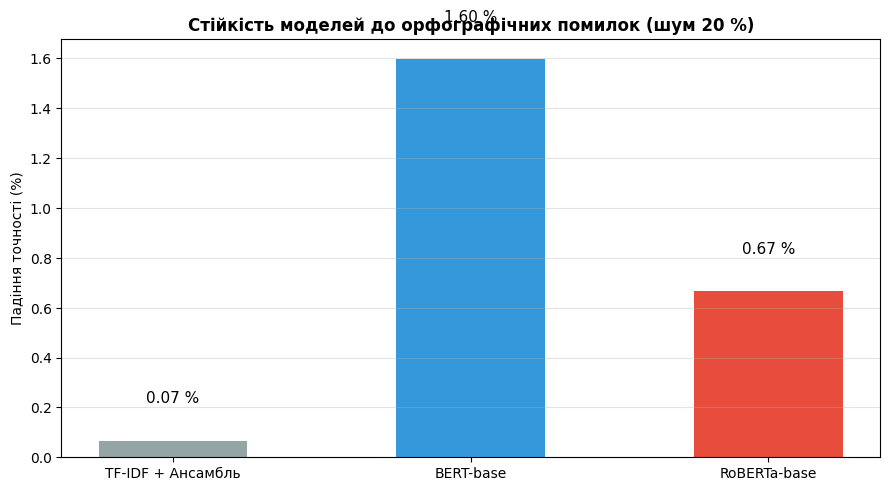

Графік збережено: robustness_test.png


In [ ]:
# @title Тест на стійкість до шуму
def add_noise(text: str, noise_level: float = 0.2) -> str:
    """Додає випадкові орфографічні помилки (заміна символів)."""
    words = text.split()
    if not words:
        return text
    n_noise = max(1, int(len(words) * noise_level))
    for _ in range(n_noise):
        idx = random.randint(0, len(words) - 1)
        if len(words[idx]) > 3:
            pos = random.randint(0, len(words[idx]) - 1)
            words[idx] = (
                words[idx][:pos]
                + random.choice(string.ascii_lowercase)
                + words[idx][pos + 1:]
            )
    return ' '.join(words)

print('ТЕСТ НА СТІЙКІСТЬ ДО ШУМУ (рівень шуму: 20 %)')
print('=' * 55)

N_NOISE   = min(200, len(X_test))
test_idx  = np.random.choice(len(X_test), N_NOISE, replace=False)
clean_txt = [X_test[i] for i in test_idx]
true_lbl  = y_test[test_idx]
noisy_txt = [add_noise(t) for t in clean_txt]

noise_results = []

# Базова модель
X_noisy_tfidf   = tfidf.transform(noisy_txt)
noisy_pred_base = ensemble.predict(X_noisy_tfidf)
noisy_acc_base  = accuracy_score(true_lbl, noisy_pred_base)
drop_base       = (test_acc_base - noisy_acc_base) / test_acc_base * 100
noise_results.append(['TF-IDF + Ансамбль', noisy_acc_base, drop_base])

# BERT
bert_noise_ds  = TextDataset(noisy_txt, true_lbl, bert_tokenizer)
bert_noise_out = trainer_bert.predict(bert_noise_ds)
noisy_pred_bert = np.argmax(bert_noise_out.predictions, axis=1)
noisy_acc_bert  = accuracy_score(true_lbl, noisy_pred_bert)
drop_bert       = (bert_acc - noisy_acc_bert) / bert_acc * 100
noise_results.append(['BERT-base', noisy_acc_bert, drop_bert])

# RoBERTa
rob_noise_ds   = TextDataset(noisy_txt, true_lbl, roberta_tokenizer)
rob_noise_out  = trainer_roberta.predict(rob_noise_ds)
noisy_pred_rob = np.argmax(rob_noise_out.predictions, axis=1)
noisy_acc_rob  = accuracy_score(true_lbl, noisy_pred_rob)
drop_rob       = (roberta_acc - noisy_acc_rob) / roberta_acc * 100
noise_results.append(['RoBERTa-base', noisy_acc_rob, drop_rob])

# Таблиця
print()
print('┌──────────────────────┬──────────────────┬──────────────┐')
print('│ Модель               │ Точність (шум)   │ Падіння (%)  │')
print('├──────────────────────┼──────────────────┼──────────────┤')
for row in noise_results:
    print(f'│ {row[0]:<20} │ {row[1]:>14.4f}   │ {row[2]:>10.2f}   │')
print('└──────────────────────┴──────────────────┴──────────────┘')

# Діаграма
plt.figure(figsize=(9, 5))
colors = ['#95a5a6', '#3498db', '#e74c3c']
bars = plt.bar([r[0] for r in noise_results], [r[2] for r in noise_results], color=colors, width=0.5)
for bar, row in zip(bars, noise_results):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.15,
             f'{row[2]:.2f} %', ha='center', fontsize=11)
plt.ylabel('Падіння точності (%)')
plt.title('Стійкість моделей до орфографічних помилок (шум 20 %)', fontweight='bold')
plt.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.savefig('robustness_test.png', dpi=150)
plt.show()
print('Графік збережено: robustness_test.png')


In [ ]:
# @title Статистична значущість (BERT vs RoBERTa)
print('СТАТИСТИЧНА ЗНАЧУЩІСТЬ: BERT vs RoBERTa (тест Макнемара)')
print('=' * 60)

# Таблиця 2×2 — випадки, де моделі розходяться
b00, b01, b10, b11 = 0, 0, 0, 0
for i in range(len(y_test)):
    bc = (bert_preds[i]    == y_test[i])
    rc = (roberta_preds[i] == y_test[i])
    if     bc and     rc: b00 += 1
    elif   bc and not rc: b01 += 1
    elif not bc and     rc: b10 += 1
    else:                  b11 += 1

contingency = [[b00, b01], [b10, b11]]

print()
print('  Таблиця збіжності передбачень:')
print('  ┌──────────────────────┬──────────────────┬──────────────────┐')
print('  │                      │  BERT правильно  │  BERT помилка    │')
print('  ├──────────────────────┼──────────────────┼──────────────────┤')
print(f'  │ RoBERTa правильно   │ {b00:>14,}   │ {b10:>14,}   │')
print(f'  │ RoBERTa помилка     │ {b01:>14,}   │ {b11:>14,}   │')
print('  └──────────────────────┴──────────────────┴──────────────────┘')

mcnemar_result = mcnemar(contingency, exact=True)
p_val = mcnemar_result.pvalue
alpha = 0.05

print(f'\n  p-значення: {p_val:.4f}  (рівень значущості α = {alpha})')
print()
if p_val < alpha:
    better = 'RoBERTa-base' if roberta_acc > bert_acc else 'BERT-base'
    print(f'  Різниця між моделями СТАТИСТИЧНО ЗНАЧУЩА (p < {alpha}).')
    print(f'  → Модель {better} демонструє достовірно кращі результати.')
else:
    print(f'  Різниця між моделями статистично НЕ значуща (p ≥ {alpha}).')
    print('  → Обидві моделі показують порівнянну якість класифікації.')

print()
print('=' * 60)
print('ПІДСУМОК ДОСЛІДЖЕННЯ')
print('=' * 60)
best_model = max(
    [('TF-IDF + Ансамбль', test_acc_base), ('BERT-base', bert_acc), ('RoBERTa-base', roberta_acc)],
    key=lambda x: x[1]
)
print(f'  Найкраща модель за Accuracy : {best_model[0]} ({best_model[1]:.4f})')
best_f1 = max(
    [('TF-IDF + Ансамбль', test_f1_base), ('BERT-base', bert_f1), ('RoBERTa-base', roberta_f1)],
    key=lambda x: x[1]
)
print(f'  Найкраща модель за F1       : {best_f1[0]} ({best_f1[1]:.4f})')
best_auc = max(
    [('TF-IDF + Ансамбль', test_auc_base), ('BERT-base', bert_auc), ('RoBERTa-base', roberta_auc)],
    key=lambda x: x[1]
)
print(f'  Найкраща модель за ROC-AUC  : {best_auc[0]} ({best_auc[1]:.4f})')
print()
most_robust = min(noise_results, key=lambda x: x[2])
print(f'  Найстійкіша до шуму        : {most_robust[0]} (падіння {most_robust[2]:.2f} %)')
print()
lightest = min(
    [('TF-IDF + Ансамбль', base_size_mb), ('BERT-base', bert_size_mb), ('RoBERTa-base', roberta_size_mb)],
    key=lambda x: x[1]
)
print(f'  Найлегша модель            : {lightest[0]} ({lightest[1]:.1f} MB)')
print('=' * 60)


СТАТИСТИЧНА ЗНАЧУЩІСТЬ: BERT vs RoBERTa (тест Макнемара)

  Таблиця збіжності передбачень:
  ┌──────────────────────┬──────────────────┬──────────────────┐
  │                      │  BERT правильно  │  BERT помилка    │
  ├──────────────────────┼──────────────────┼──────────────────┤
  │ RoBERTa правильно   │          1,469   │             26   │
  │ RoBERTa помилка     │              2   │              3   │
  └──────────────────────┴──────────────────┴──────────────────┘

  p-значення: 0.0000  (рівень значущості α = 0.05)

  Різниця між моделями СТАТИСТИЧНО ЗНАЧУЩА (p < 0.05).
  → Модель RoBERTa-base демонструє достовірно кращі результати.

ПІДСУМОК ДОСЛІДЖЕННЯ
  Найкраща модель за Accuracy : RoBERTa-base (0.9967)
  Найкраща модель за F1       : RoBERTa-base (0.9967)
  Найкраща модель за ROC-AUC  : RoBERTa-base (0.9997)

  Найстійкіша до шуму        : TF-IDF + Ансамбль (падіння 0.07 %)

  Найлегша модель            : TF-IDF + Ансамбль (3.0 MB)


In [ ]:
# @title Комірка 18 — Інтерактивна перевірка тексту
def predict_text(text: str, verbose: bool = True) -> dict:
    """
    Приймає текст, повертає передбачення всіх трьох моделей.
    """
    results = {}

    # ── TF-IDF + Ансамбль ─────────────────────────────────
    vec = tfidf.transform([text])
    pred_base  = ensemble.predict(vec)[0]
    proba_base = ensemble.predict_proba(vec)[0]
    results['TF-IDF + Ансамбль'] = {
        'label': pred_base,
        'prob_human': proba_base[0],
        'prob_ai':    proba_base[1]
    }

    # ── BERT ──────────────────────────────────────────────
    ds_bert = TextDataset([text], [0], bert_tokenizer)
    out_bert = trainer_bert.predict(ds_bert)
    proba_bert = torch.nn.functional.softmax(
        torch.from_numpy(out_bert.predictions), dim=-1
    ).numpy()[0]
    results['BERT-base'] = {
        'label':      int(np.argmax(proba_bert)),
        'prob_human': proba_bert[0],
        'prob_ai':    proba_bert[1]
    }

    # ── RoBERTa ────────────────────────────────────────────
    ds_rob = TextDataset([text], [0], roberta_tokenizer)
    out_rob = trainer_roberta.predict(ds_rob)
    proba_rob = torch.nn.functional.softmax(
        torch.from_numpy(out_rob.predictions), dim=-1
    ).numpy()[0]
    results['RoBERTa-base'] = {
        'label':      int(np.argmax(proba_rob)),
        'prob_human': proba_rob[0],
        'prob_ai':    proba_rob[1]
    }

    if verbose:
        print('─' * 55)
        print(f'ТЕКСТ ({len(text.split())} слів): {text[:80]}...')
        print('─' * 55)
        print(f'  {"Модель":<22} │ {"Вердикт":<10} │ Людина  │  ШІ')
        print(f'  {"─"*22}─┼─{"─"*10}─┼─{"─"*7}─┼─{"─"*6}')
        votes = []
        for model_name, res in results.items():
            verdict = 'ШІ' if res['label'] == 1 else 'Людина'
            votes.append(res['label'])
            print(f'  {model_name:<22} │ {verdict:<12} │ {res["prob_human"]:.3f}   │ {res["prob_ai"]:.3f}')
        print('─' * 55)

        # Фінальний вердикт — більшість голосів
        final = 1 if sum(votes) >= 2 else 0
        confidence = max(
            np.mean([r['prob_ai'] for r in results.values()]),
            np.mean([r['prob_human'] for r in results.values()])
        )
        verdict_str = 'ШІ' if final == 1 else 'Людина'
        print(f'  ФІНАЛЬНИЙ ВЕРДИКТ: {verdict_str}  (впевненість: {confidence:.1%})')
        print('─' * 55)

    return results

MY_TEXT = """
"""

predict_text(MY_TEXT)

───────────────────────────────────────────────────────
ТЕКСТ (385 слів): 
I thought I got lucky.

Rent was cheap, the place looked decent, and the guy al...
───────────────────────────────────────────────────────
  Модель                 │ Вердикт    │ Людина  │  ШІ
  ───────────────────────┼────────────┼─────────┼───────
  TF-IDF + Ансамбль      │ Людина       │ 0.651   │ 0.349
  BERT-base              │ ШІ           │ 0.004   │ 0.996
  RoBERTa-base           │ Людина       │ 0.910   │ 0.090
───────────────────────────────────────────────────────
  ФІНАЛЬНИЙ ВЕРДИКТ: Людина  (впевненість: 52.1%)
───────────────────────────────────────────────────────


{'TF-IDF + Ансамбль': {'label': np.int64(0),
  'prob_human': np.float64(0.6505358165484987),
  'prob_ai': np.float64(0.3494641834515013)},
 'BERT-base': {'label': 1,
  'prob_human': np.float32(0.003831932),
  'prob_ai': np.float32(0.9961681)},
 'RoBERTa-base': {'label': 0,
  'prob_human': np.float32(0.91006696),
  'prob_ai': np.float32(0.08993301)}}

In [ ]:
# @title Завантаження HC3
import pandas as pd
import numpy as np
import requests
import json

print("Завантаження HC3 (all.jsonl) з Hugging Face...")

URL = (
    "https://huggingface.co/datasets/Hello-SimpleAI/HC3"
    "/resolve/main/all.jsonl"
)

resp = requests.get(URL, timeout=120)
resp.raise_for_status()
print(f"Файл завантажено: {len(resp.content)/1e6:.1f} MB")

# Парсинг JSONL
rows = []
for line in resp.text.splitlines():
    line = line.strip()
    if not line:
        continue
    item = json.loads(line)
    # Кожен рядок: {"question": ..., "human_answers": [...], "chatgpt_answers": [...], "source": ...}
    for ans in (item.get("human_answers") or []):
        if ans and len(str(ans).strip()) > 50:
            rows.append({
                "text":   str(ans).strip(),
                "label":  0,
                "source": item.get("source", "unknown")
            })
    for ans in (item.get("chatgpt_answers") or []):
        if ans and len(str(ans).strip()) > 50:
            rows.append({
                "text":   str(ans).strip(),
                "label":  1,
                "source": item.get("source", "unknown")
            })

hc3_df = (
    pd.DataFrame(rows)
    .drop_duplicates(subset="text")
    .reset_index(drop=True)
)

print(f"\nРозмір HC3: {len(hc3_df):,} записів")
print(f"Джерела: {hc3_df['source'].unique().tolist()}")

print("\nРозподіл класів:")
for label, count in hc3_df["label"].value_counts().sort_index().items():
    name = "Людина" if label == 0 else "ChatGPT"
    print(f"  {name} ({label}): {count:,} ({count/len(hc3_df)*100:.1f}%)")

hc3_df["word_count"] = hc3_df["text"].str.split().str.len()
print(f"\nДовжина текстів (слів): "
      f"mean={hc3_df['word_count'].mean():.0f}, "
      f"median={hc3_df['word_count'].median():.0f}")

Завантаження HC3 (all.jsonl) з Hugging Face...
Файл завантажено: 73.7 MB

Розмір HC3: 78,444 записів
Джерела: ['reddit_eli5', 'open_qa', 'wiki_csai', 'finance', 'medicine']

Розподіл класів:
  Людина (0): 52,224 (66.6%)
  ChatGPT (1): 26,220 (33.4%)

Довжина текстів (слів): mean=149, median=123


In [ ]:
# @title Формування збалансованої тестової вибірки HC3
HC3_SAMPLE = min(
    750,
    hc3_df[hc3_df["label"] == 0].shape[0],
    hc3_df[hc3_df["label"] == 1].shape[0]
)

hc3_balanced = pd.concat([
    hc3_df[hc3_df["label"] == 0].sample(HC3_SAMPLE, random_state=SEED),
    hc3_df[hc3_df["label"] == 1].sample(HC3_SAMPLE, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

X_hc3 = hc3_balanced["text"].values
y_hc3 = hc3_balanced["label"].values

print(f"Тестова вибірка HC3: {len(X_hc3)} текстів "
      f"(Людина={sum(y_hc3==0)}, ChatGPT={sum(y_hc3==1)})")
print(f"Середня довжина: {np.mean([len(t.split()) for t in X_hc3]):.0f} слів")

Тестова вибірка HC3: 1500 текстів (Людина=750, ChatGPT=750)
Середня довжина: 154 слів


In [ ]:
# @title Тестування моделей на HC3 (cross-domain )
import time

hc3_results = {}

# ── TF-IDF + Ансамбль ──────────────────────────────────────
t0 = time.time()
X_hc3_tfidf = tfidf.transform(X_hc3)
pred_base    = ensemble.predict(X_hc3_tfidf)
proba_base   = ensemble.predict_proba(X_hc3_tfidf)[:, 1]
hc3_results["TF-IDF + Ансамбль"] = {
    "preds": pred_base, "probs": proba_base,
    "acc":  accuracy_score(y_hc3, pred_base),
    "f1":   f1_score(y_hc3, pred_base, average="weighted"),
    "auc":  roc_auc_score(y_hc3, proba_base),
    "time": (time.time() - t0) * 1000 / len(X_hc3)
}

# ── BERT ───────────────────────────────────────────────────
t0 = time.time()
hc3_ds_bert = TextDataset(X_hc3, y_hc3, bert_tokenizer)
out_bert     = trainer_bert.predict(hc3_ds_bert)
pred_bert    = np.argmax(out_bert.predictions, axis=1)
proba_bert   = torch.nn.functional.softmax(
    torch.from_numpy(out_bert.predictions), dim=-1).numpy()[:, 1]
hc3_results["BERT-base"] = {
    "preds": pred_bert, "probs": proba_bert,
    "acc":  accuracy_score(y_hc3, pred_bert),
    "f1":   f1_score(y_hc3, pred_bert, average="weighted"),
    "auc":  roc_auc_score(y_hc3, proba_bert),
    "time": (time.time() - t0) * 1000 / len(X_hc3)
}

# ── RoBERTa ────────────────────────────────────────────────
t0 = time.time()
hc3_ds_rob = TextDataset(X_hc3, y_hc3, roberta_tokenizer)
out_rob     = trainer_roberta.predict(hc3_ds_rob)
pred_rob    = np.argmax(out_rob.predictions, axis=1)
proba_rob   = torch.nn.functional.softmax(
    torch.from_numpy(out_rob.predictions), dim=-1).numpy()[:, 1]
hc3_results["RoBERTa-base"] = {
    "preds": pred_rob, "probs": proba_rob,
    "acc":  accuracy_score(y_hc3, pred_rob),
    "f1":   f1_score(y_hc3, pred_rob, average="weighted"),
    "auc":  roc_auc_score(y_hc3, proba_rob),
    "time": (time.time() - t0) * 1000 / len(X_hc3)
}

# ── Таблиця результатів ────────────────────────────────────
print("\nРЕЗУЛЬТАТИ НА HC3 (cross-domain тест)")
print("=" * 65)
print(f"{'Модель':<22} {'Accuracy':>9} {'F1':>9} {'ROC-AUC':>9} {'мс/текст':>9}")
print("─" * 65)
for name, r in hc3_results.items():
    print(f"{name:<22} {r['acc']:>9.4f} {r['f1']:>9.4f} "
          f"{r['auc']:>9.4f} {r['time']:>9.2f}")
print("=" * 65)

# ── Деталізований звіт для RoBERTa ────────────────────────
print("\nКласифікаційний звіт RoBERTa (HC3):")
print(classification_report(
    y_hc3, hc3_results["RoBERTa-base"]["preds"],
    target_names=["Людина", "ChatGPT"]
))

# ── Порівняння: DAIGT vs HC3 ───────────────────────────────
print("\nПОРІВНЯННЯ: навчальний домен vs HC3")
print(f"{'Модель':<22} {'DAIGT Acc':>10} {'HC3 Acc':>10} {'Δ (пп)':>10}")
print("─" * 55)
daigt_acc = {
    "TF-IDF + Ансамбль": test_acc_base,
    "BERT-base":          bert_acc,
    "RoBERTa-base":       roberta_acc
}
for name, r in hc3_results.items():
    delta = (r["acc"] - daigt_acc[name]) * 100
    sign  = "+" if delta >= 0 else ""
    print(f"{name:<22} {daigt_acc[name]:>10.4f} {r['acc']:>10.4f} "
          f"{sign}{delta:>8.2f}")


РЕЗУЛЬТАТИ НА HC3 (cross-domain тест)
Модель                  Accuracy        F1   ROC-AUC  мс/текст
─────────────────────────────────────────────────────────────────
TF-IDF + Ансамбль         0.5913    0.5445    0.7243      0.41
BERT-base                 0.7420    0.7246    0.9609      7.76
RoBERTa-base              0.9260    0.9259    0.9818      5.20

Класифікаційний звіт RoBERTa (HC3):
              precision    recall  f1-score   support

      Людина       0.96      0.89      0.92       750
     ChatGPT       0.90      0.96      0.93       750

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500


ПОРІВНЯННЯ: навчальний домен vs HC3
Модель                  DAIGT Acc    HC3 Acc     Δ (пп)
───────────────────────────────────────────────────────
TF-IDF + Ансамбль          0.9907     0.5913   -39.93
BERT-base                  0.9807     0.7420   -23.87
RoBERTa-base          

In [ ]:
# @title Причина 1 - Перевірка дублікатів між train/val/test

from sklearn.metrics.pairwise import cosine_similarity
import hashlib

print("=" * 60)
print("ПРИЧИНА 1: ПЕРЕВІРКА ДУБЛІКАТІВ")
print("=" * 60)

# ── Точні дублікати ──────────────────────────────────────
def text_hash(t): return hashlib.md5(str(t).strip().lower().encode()).hexdigest()

hashes_train = set(text_hash(t) for t in X_train)
hashes_val   = set(text_hash(t) for t in X_val)
hashes_test  = set(text_hash(t) for t in X_test)

exact_tv = len(hashes_train & hashes_val)
exact_tt = len(hashes_train & hashes_test)
exact_vt = len(hashes_val  & hashes_test)

print(f"\n[1a] Точні дублікати:")
print(f"  Train ∩ Val  : {exact_tv}")
print(f"  Train ∩ Test : {exact_tt}  ← найважливіше")
print(f"  Val   ∩ Test : {exact_vt}")

# ── Майже-дублікати через TF-IDF cosine similarity ───────
print(f"\n[1b] Майже-дублікати (cosine similarity > 0.95):")

# Беремо підвибірку для швидкості
N_CHECK = min(500, len(X_train), len(X_test))
idx_tr  = np.random.choice(len(X_train), N_CHECK, replace=False)
idx_te  = np.random.choice(len(X_test),  N_CHECK, replace=False)

X_tr_sub = tfidf.transform([X_train[i] for i in idx_tr])
X_te_sub = tfidf.transform([X_test[i]  for i in idx_te])

sim_matrix = cosine_similarity(X_te_sub, X_tr_sub)
near_dups  = int((sim_matrix > 0.95).sum())

print(f"  Пар з cosine > 0.95 (підвибірка {N_CHECK}×{N_CHECK}): {near_dups}")

if exact_tt == 0 and near_dups < 5:
    print("\nДублікатів НЕ виявлено - причина 1 не підтверджується.")
else:
    print("\n ЗНАЙДЕНО дублікати - потенційний витік даних!")

total_rows   = len(df_sample)
unique_texts = df_sample['text'].nunique()
print(f"\n[1c] Загальна перевірка df_sample:")
print(f"  Всього рядків : {total_rows}")
print(f"  Унікальних    : {unique_texts}")
print(f"  Дублікатів    : {total_rows - unique_texts}")

ПРИЧИНА 1: ПЕРЕВІРКА ДУБЛІКАТІВ

[1a] Точні дублікати:
  Train ∩ Val  : 0
  Train ∩ Test : 0  ← найважливіше
  Val   ∩ Test : 0

[1b] Майже-дублікати (cosine similarity > 0.95):
  Пар з cosine > 0.95 (підвибірка 500×500): 0

Дублікатів НЕ виявлено - причина 1 не підтверджується.

[1c] Загальна перевірка df_sample:
  Всього рядків : 10000
  Унікальних    : 10000
  Дублікатів    : 0


ПРИЧИНА 2: АНАЛІЗ ТЕМ

[2a] Найхарактерніші слова за класом (TF-IDF):

  Людина — топ-20 слів:
  students, school, people, car, cars, venus, electoral, think, just, like, student, vote, help, phones, college, time, driving, good, want, community

  ШІ — топ-20 слів:
  students, electoral, like, college, car, school, usage, important, help, people, learning, time, states, make, vote, limiting, success, positive, cars, work

[2b] LDA тематичне моделювання (5 тем):

  Розподіл текстів по темах (% від класу):
        Людина (%)  ШІ (%)
Тема 0         7.9    53.4
Тема 1        25.4    14.9
Тема 2        13.4    10.1
Тема 3        34.7     7.3
Тема 4        18.5    14.2

  Ключові слова тем:
  Тема 0: students, school, learning, work, help, important, time, student
  Тема 1: like, people, just, think, make, know, phones, school
  Тема 2: electoral, college, vote, states, president, students, popular, summer
  Тема 3: students, school, venus, help, activities, student, community, like
  Тема 

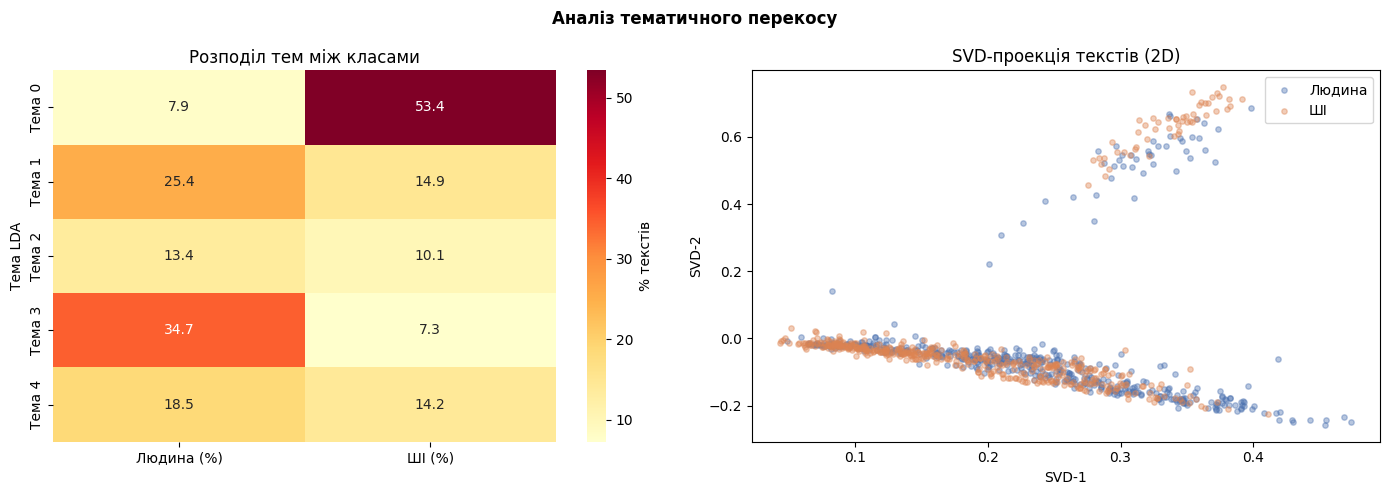

Збережено: topic_analysis.png

  Максимальна різниця розподілу тем між класами: 45.5%
  ⚠️  ЗНАЧНИЙ тематичний перекіс — модель могла вловити тему!


In [ ]:
# @title Причина 2 - Аналіз тем

from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("ПРИЧИНА 2: АНАЛІЗ ТЕМ")
print("=" * 60)

# ── 2a. Топ-слова для кожного класу ─────────────────────────
print("\n[2a] Найхарактерніші слова за класом (TF-IDF):")

tfidf_diag = TfidfVectorizer(max_features=10000, ngram_range=(1,1),
                              stop_words='english', min_df=3)
tfidf_diag.fit(list(X_train) + list(X_test))
vocab = np.array(tfidf_diag.get_feature_names_out())

for label, name in [(0, 'Людина'), (1, 'ШІ')]:
    mask  = (np.concatenate([y_train, y_test]) == label)
    texts = np.concatenate([X_train, X_test])[mask]
    vecs  = tfidf_diag.transform(texts)
    scores = np.asarray(vecs.mean(axis=0)).flatten()
    top_idx = scores.argsort()[-20:][::-1]
    print(f"\n  {name} — топ-20 слів:")
    print("  " + ", ".join(vocab[top_idx]))

# ── 2b. LDA — тематичне моделювання ─────────────────────────
print("\n[2b] LDA тематичне моделювання (5 тем):")

cv = CountVectorizer(max_features=5000, stop_words='english', min_df=5)

all_texts  = np.concatenate([X_train, X_test])
all_labels = np.concatenate([y_train, y_test])
cv_matrix  = cv.fit_transform(all_texts)
cv_vocab   = np.array(cv.get_feature_names_out())

lda = LatentDirichletAllocation(n_components=5, random_state=SEED,
                                 max_iter=10, n_jobs=-1)
lda.fit(cv_matrix)
topic_dist = lda.transform(cv_matrix)   # (N, 5)

# Домінуюча тема для кожного тексту
dominant_topic = topic_dist.argmax(axis=1)

# Розподіл тем по класах
topic_df = pd.DataFrame({
    'topic': dominant_topic,
    'label': all_labels
})
topic_cross = pd.crosstab(topic_df['topic'], topic_df['label'],
                           normalize='columns') * 100
topic_cross.columns = ['Людина (%)', 'ШІ (%)']
topic_cross.index   = [f'Тема {i}' for i in range(5)]

print("\n  Розподіл текстів по темах (% від класу):")
print(topic_cross.round(1).to_string())

# Ключові слова тем
print("\n  Ключові слова тем:")
for i, comp in enumerate(lda.components_):
    top_words = cv_vocab[comp.argsort()[-8:][::-1]]
    print(f"  Тема {i}: {', '.join(top_words)}")

# ── 2c. Візуалізація ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Аналіз тематичного перекосу', fontweight='bold')

# Heatmap тем
sns.heatmap(topic_cross, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': '% текстів'})
axes[0].set_title('Розподіл тем між класами')
axes[0].set_ylabel('Тема LDA')

# SVD 2D проекція
svd = TruncatedSVD(n_components=2, random_state=SEED)
coords = svd.fit_transform(tfidf_diag.transform(all_texts))
sample_idx = np.random.choice(len(coords), 1000, replace=False)
for lbl, col, nm in [(0,'#4C72B0','Людина'),(1,'#DD8452','ШІ')]:
    mask = all_labels[sample_idx] == lbl
    axes[1].scatter(coords[sample_idx][mask, 0],
                    coords[sample_idx][mask, 1],
                    c=col, alpha=0.4, s=15, label=nm)
axes[1].set_title('SVD-проекція текстів (2D)')
axes[1].set_xlabel('SVD-1'); axes[1].set_ylabel('SVD-2')
axes[1].legend()

plt.tight_layout()
plt.savefig('topic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Збережено: topic_analysis.png")

# ── 2d. Висновок ─────────────────────────────────────────────
max_diff = (topic_cross['Людина (%)'] - topic_cross['ШІ (%)']).abs().max()
print(f"\n  Максимальна різниця розподілу тем між класами: {max_diff:.1f}%")
if max_diff > 20:
    print("   ЗНАЧНИЙ тематичний перекіс - модель могла вловити тему!")
else:
    print("   Теми розподілені рівномірно - причина 2 малоймовірна.")

ПРИЧИНА 3: АНАЛІЗ ДЖЕРЕЛ ТА СТИЛЮ

[3a] Розподіл по колонці 'source':
source  NousResearch/Llama-2-7b-chat-hf  chat_gpt_moth  cohere-command  darragh_claude_v6  darragh_claude_v7  falcon_180b_v1  kingki19_palm  llama2_chat  llama_70b_v1  mistral7binstruct_v1  mistral7binstruct_v2  mistralai/Mistral-7B-Instruct-v0.1  palm-text-bison1  persuade_corpus  radek_500  radekgpt4  train_essays
Людина                                0              0               0                  0                  0               0              0            0             0                     0                     0                                   0                 0            25996          0          0          1375
ШІ                                  400           2421             350               1000               1000            1055           1384         2421          1172                  2421                  2421                                 400               349                0        500  

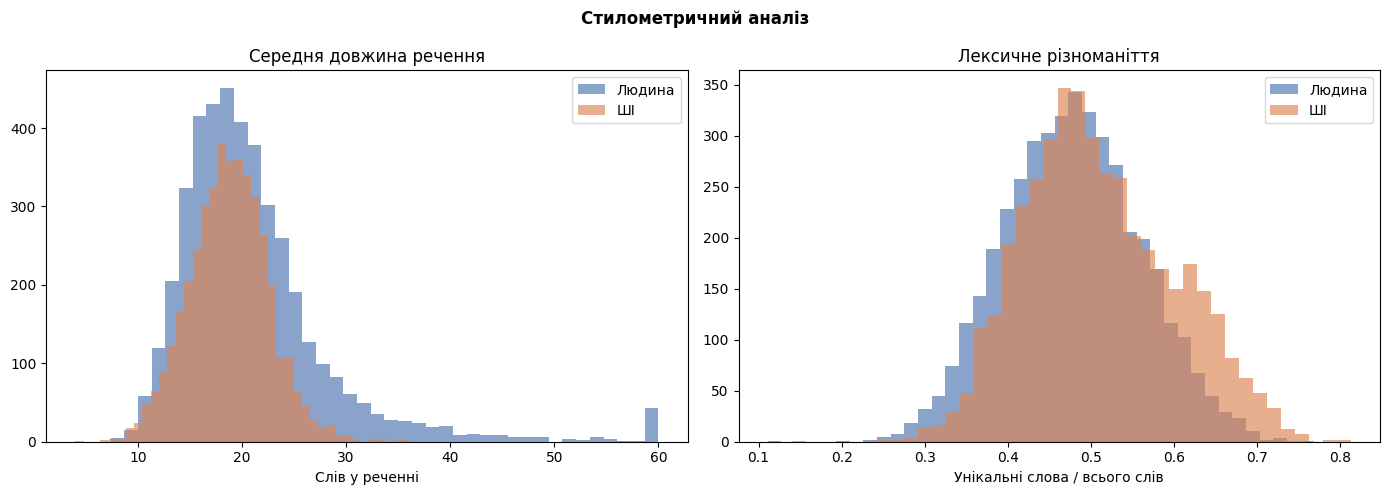

Збережено: stylometry_analysis.png


In [ ]:
# @title Причина 3 — Аналіз джерел та стилю генерації

print("=" * 60)
print("ПРИЧИНА 3: АНАЛІЗ ДЖЕРЕЛ ТА СТИЛЮ")
print("=" * 60)

# ── 3a. Розподіл джерел у датасеті ──────────────────────────
print("\n[3a] Розподіл по колонці 'source':")
if 'source' in df.columns:
    src_by_label = df.groupby(['label','source']).size().unstack(fill_value=0)
    src_by_label.index = ['Людина', 'ШІ']
    print(src_by_label.to_string())
else:
    print("  Колонка 'source' відсутня — перевіряємо 'prompt_name'")

print("\n[3b] Розподіл по колонці 'prompt_name':")
if 'prompt_name' in df.columns:
    pn = df.groupby(['label','prompt_name']).size().unstack(fill_value=0)
    pn.index = ['Людина', 'ШІ']
    print(pn.head(15).to_string())

# ── 3c. Стилометричні ознаки ─────────────────────────────────
print("\n[3c] Стилометричні ознаки (Train+Test разом):")

all_texts  = np.concatenate([X_train, X_test])
all_labels = np.concatenate([y_train, y_test])

import re

def stylometry(text):
    words    = text.split()
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if s.strip()]
    chars    = len(text)
    n_words  = len(words) if words else 1
    n_sents  = len(sentences) if sentences else 1

    avg_word_len  = np.mean([len(w) for w in words]) if words else 0
    avg_sent_len  = n_words / n_sents
    punct_ratio   = sum(1 for c in text if c in '.,;:!?') / chars if chars else 0
    unique_ratio  = len(set(w.lower() for w in words)) / n_words  # lexical diversity
    comma_per_sent = text.count(',') / n_sents

    return {
        'avg_word_len'  : avg_word_len,
        'avg_sent_len'  : avg_sent_len,
        'punct_ratio'   : punct_ratio,
        'lexical_div'   : unique_ratio,
        'comma_per_sent': comma_per_sent,
    }

style_rows = [stylometry(t) for t in all_texts]
style_df   = pd.DataFrame(style_rows)
style_df['label'] = all_labels
style_df['class'] = style_df['label'].map({0:'Людина', 1:'ШІ'})

style_summary = style_df.groupby('class')[
    ['avg_word_len','avg_sent_len','punct_ratio','lexical_div','comma_per_sent']
].mean().round(3)
print(style_summary.to_string())

# ── 3d. Наскільки роздільні стилометричні ознаки ─────────────
from sklearn.linear_model import LogisticRegression as LR
from sklearn.preprocessing import StandardScaler

feat_cols = ['avg_word_len','avg_sent_len','punct_ratio','lexical_div','comma_per_sent']
X_style = style_df[feat_cols].values
y_style = style_df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_style)

# 5-fold CV на стилометрії
from sklearn.model_selection import cross_val_score
style_lr  = LR(max_iter=500, random_state=SEED)
cv_scores = cross_val_score(style_lr, X_scaled, y_style, cv=5, scoring='accuracy')
print(f"\n[3d] Accuracy лише по стилометрії (5-fold CV): "
      f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
if cv_scores.mean() > 0.80:
    print("  Стилометрія САМА по собі дає >80% — "
          "модель вловила стиль, не генерацію!")
else:
    print("  Стилометрія слабка — стиль не є головним чинником.")

# ── 3e. Візуалізація ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Стилометричний аналіз', fontweight='bold')

# Розподіл середньої довжини речення
for lbl, col, nm in [(0,'#4C72B0','Людина'),(1,'#DD8452','ШІ')]:
    vals = style_df[style_df['label']==lbl]['avg_sent_len'].clip(upper=60)
    axes[0].hist(vals, bins=40, alpha=0.65, color=col, label=nm)
axes[0].set_title('Середня довжина речення')
axes[0].set_xlabel('Слів у реченні'); axes[0].legend()

# Лексичне різноманіття
for lbl, col, nm in [(0,'#4C72B0','Людина'),(1,'#DD8452','ШІ')]:
    vals = style_df[style_df['label']==lbl]['lexical_div']
    axes[1].hist(vals, bins=40, alpha=0.65, color=col, label=nm)
axes[1].set_title('Лексичне різноманіття')
axes[1].set_xlabel('Унікальні слова / всього слів'); axes[1].legend()

plt.tight_layout()
plt.savefig('stylometry_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Збережено: stylometry_analysis.png")